# Ekman Emotion Classifier + Sarcasm Detection
**Model:** DistilBERT fine-tuned on GoEmotions → remapped to Ekman's 6 emotions  
**Pipeline:** Sarcasm detection → Emotion classification → Post-processing  
**Baseline:** TF-IDF + Logistic Regression for comparison

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
# Run once. Restart kernel after installation.

!pip install transformers datasets torch accelerate scikit-learn seaborn matplotlib --quiet

In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Torch version: {torch.__version__}")

/home/imran/NLP/group_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Torch version: 2.12.0+cu130


In [ ]:
# ── Cell 3: Config — all hyperparameters in one place ─────────────────────────

MODEL_NAME        = "distilbert/distilroberta-base"
MAX_LENGTH        = 128
BATCH_SIZE        = 16
EVAL_BATCH_SIZE   = 32
LEARNING_RATE     = 2e-5
NUM_EPOCHS        = 5
WARMUP_RATIO      = 0.1
WEIGHT_DECAY      = 0.01
SARCASM_THRESHOLD = 0.5   # Confidence above which we apply the flip map

EMOTION_OUTPUT_DIR  = "./models/ekman-emotion"
SARCASM_OUTPUT_DIR  = "./models/sarcasm-detector"

EKMAN_LABELS = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
NUM_LABELS   = len(EKMAN_LABELS)

# Ekman sarcasm flip map — what sarcasm typically inverts
SARCASM_FLIP_MAP = {
    0: 3,  # anger   → joy      (rare but e.g. "oh i just LOVE being ignored")
    1: 1,  # disgust → disgust  (sarcasm rarely inverts disgust)
    2: 2,  # fear    → fear     (rarely inverted)
    3: 4,  # joy     → sadness  (most common: "oh great, another Monday")
    4: 3,  # sadness → joy
    5: 5,  # surprise→ surprise (sarcastic surprise is still surprise)
    6: 6,  # neutral → neutral (neutral is not inverted)
}

os.makedirs(EMOTION_OUTPUT_DIR, exist_ok=True)
os.makedirs(SARCASM_OUTPUT_DIR, exist_ok=True)
print("Config ready.")

Config ready.


In [71]:
# ── Cell 4: GoEmotions → Ekman label mapping ───────────────────────────────────
# Official Google mapping. Each GoEmotions label maps to one Ekman class (or None to drop).

GOEMOTIONS_TO_EKMAN = {
    # anger
    "anger":       "anger",
    "annoyance":   "anger",
    "disapproval": "anger",
    # disgust
    "disgust":     "disgust",
    # fear
    "fear":        "fear",
    "nervousness": "fear",
    # joy
    "joy":         "joy",
    "amusement":   "joy",
    "approval":    "joy",
    "excitement":  "joy",
    "gratitude":   "joy",
    "love":        "joy",
    "optimism":    "joy",
    "relief":      "joy",
    "pride":       "joy",
    "admiration":  "joy",
    "desire":      "joy",
    "caring":      "joy",
    # sadness
    "sadness":        "sadness",
    "disappointment": "sadness",
    "embarrassment":  "sadness",
    "grief":          "sadness",
    "remorse":        "sadness",
    # surprise
    "surprise":    "surprise",
    "realization": "surprise",
    "confusion":   "surprise",
    "curiosity":   "surprise",
    # drop
    "neutral":     "neutral",
}

LABEL2ID = {label: i for i, label in enumerate(EKMAN_LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

print("Label mapping:")
for k, v in LABEL2ID.items():
    print(f"  {v}: {k}")

Label mapping:
  0: anger
  1: disgust
  2: fear
  3: joy
  4: sadness
  5: surprise
  6: neutral


In [72]:
# ── Cell 5: Load and remap GoEmotions dataset (local files) ───────────────────

import pandas as pd
from datasets import Dataset, DatasetDict

# ── Point these at your local files ───────────────────────────────────────────
DATA_FILES = {
    "train":      "GoEmotions/data/train.tsv",
    "validation": "GoEmotions/data/dev.tsv",
    "test":       "GoEmotions/data/test.tsv",
}
# GoEmotions raw format: [text, labels, id]
# 'labels' is a comma-separated list of integer label ids

GOEMOTIONS_LABEL_NAMES = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral",
]

def load_goemotions_tsv(path):
    """Load a GoEmotions .tsv into a HuggingFace Dataset.
    Each row: text \t comma_separated_label_ids \t example_id
    Returns a Dataset with one binary column per emotion label.
    """
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            text     = parts[0]
            label_ids = [int(x) for x in parts[1].split(",")]
            example_id = parts[2] if len(parts) > 2 else ""
            row = {"text": text, "id": example_id}
            for idx, name in enumerate(GOEMOTIONS_LABEL_NAMES):
                row[name] = 1 if idx in label_ids else 0
            rows.append(row)
    return Dataset.from_list(rows)

raw_ds = DatasetDict({
    split: load_goemotions_tsv(path)
    for split, path in DATA_FILES.items()
})

# rest of the cell stays identical ─────────────────────────────────────────────
EMOTION_COLS = GOEMOTIONS_LABEL_NAMES

def remap_to_ekman(example):
    active = [col for col in EMOTION_COLS if example.get(col, 0) == 1]
    ekman_votes = [GOEMOTIONS_TO_EKMAN[a] for a in active if GOEMOTIONS_TO_EKMAN.get(a)]
    if not ekman_votes:
        return {"label": -1}
    from collections import Counter
    label_str = Counter(ekman_votes).most_common(1)[0][0]
    return {"label": LABEL2ID[label_str]}

remapped = raw_ds.map(remap_to_ekman)
remapped = remapped.filter(lambda x: x["label"] != -1)

print("Split sizes after remapping:")
for split in remapped:
    print(f"  {split}: {len(remapped[split])} examples")

Filter: 100%|██████████| 5427/5427 [00:00<00:00, 98135.74 examples/s]

Split sizes after remapping:
  train: 43410 examples
  validation: 5426 examples
  test: 5427 examples


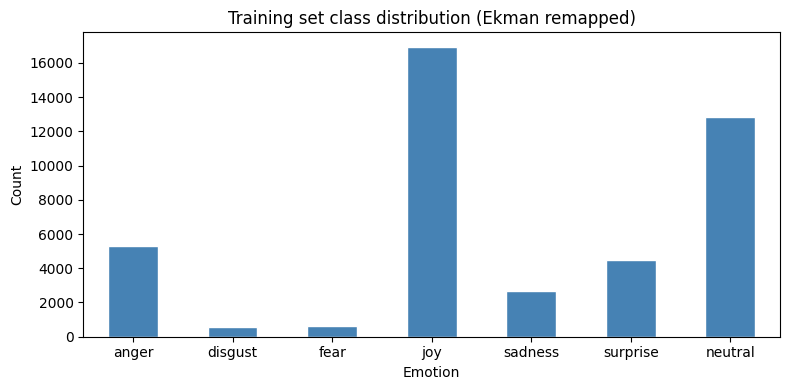

anger        5316
disgust       579
fear          618
joy         16941
sadness      2648
surprise     4485
neutral     12823
Name: count, dtype: int64


In [73]:
# ── Cell 6: Inspect class distribution ────────────────────────────────────────
# Joy will dominate. This informs whether we need class weights.

train_labels = remapped["train"]["label"]
counts = pd.Series(train_labels).value_counts().sort_index()
counts.index = [ID2LABEL[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Training set class distribution (Ekman remapped)")
ax.set_xlabel("Emotion")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(counts)

In [74]:
# ── Cell 7a: Use pre-existing GoEmotions splits ────────────────────────────────

split = DatasetDict({
    "train":      remapped["train"],
    "validation": remapped["validation"],
    "test":       remapped["test"],
})

print(f"Train: {len(split['train'])}  Val: {len(split['validation'])}  Test: {len(split['test'])}")

Train: 43410  Val: 5426  Test: 5427


In [75]:
# ── Cell 7b: Compute class weights (train split only) ──────────────────────────

from sklearn.utils.class_weight import compute_class_weight

train_labels = split["train"]["label"]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {ID2LABEL[i]}: {w:.3f}")

Class weights:
  anger: 1.167
  disgust: 10.711
  fear: 10.035
  joy: 0.366
  sadness: 2.342
  surprise: 1.383
  neutral: 0.484


In [76]:
# ── Cell 8: Tokenize the dataset ───────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized = split.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)

print("Tokenization complete.")
print(f"Sample input_ids shape: {tokenized['train'][0]['input_ids'].shape}")

Map: 100%|██████████| 5427/5427 [00:00<00:00, 6766.24 examples/s]

Tokenization complete.
Sample input_ids shape: torch.Size([128])


In [77]:
# ── Cell 9: Custom Trainer with weighted loss ──────────────────────────────────
# Override compute_loss so rare emotions like disgust/fear get more weight.

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("Custom WeightedTrainer defined.")

Custom WeightedTrainer defined.


In [78]:
# ── Cell 10: Metrics ───────────────────────────────────────────────────────────

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

print("Metrics function ready.")

Metrics function ready.


In [79]:
# ── Cell 11: Load model and set up TrainingArguments ──────────────────────────

emotion_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

training_args = TrainingArguments(
    output_dir=EMOTION_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=True,
    logging_steps=100,
    seed=SEED,
    report_to="none",  # set to "wandb" if you want experiment tracking
)

print(f"Model loaded: {emotion_model.num_parameters():,} parameters")

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 1713.42it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: distilbert/distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] 

Model loaded: 82,123,783 parameters


In [80]:
# ── Cell 12: Train emotion model ───────────────────────────────────────────────
# ~20-30 min on GPU, ~2-3 hours on CPU.
# Early stopping kicks in if macro-F1 doesn't improve for 2 consecutive epochs.

trainer = WeightedTrainer(
    model=emotion_model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(EMOTION_OUTPUT_DIR)
tokenizer.save_pretrained(EMOTION_OUTPUT_DIR)
print(f"Emotion model saved to {EMOTION_OUTPUT_DIR}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.088260,1.032142,0.625691,0.560027,0.633329
2,0.997767,1.047889,0.638592,0.578836,0.642570
3,0.844958,1.083762,0.642462,0.567184,0.646405
4,0.675887,1.151585,0.653336,0.585176,0.656851
5,0.599067,1.231703,0.659418,0.581009,0.662602


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s]

Emotion model saved to ./models/ekman-emotion


In [81]:
# ── Cell 13: TF-IDF baseline ───────────────────────────────────────────────────
# Train a simple TF-IDF + Logistic Regression on the same data.
# This is our comparison floor — if DistilBERT can't beat this, something is wrong.

train_texts  = remapped["train"]["text"]
train_labels_np = np.array(remapped["train"]["label"])
test_texts   = remapped["test"]["text"]
test_labels_np  = np.array(remapped["test"]["label"])

print("Fitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf  = vectorizer.transform(test_texts)

print("Fitting Logistic Regression...")
tfidf_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
)
tfidf_clf.fit(X_train_tfidf, train_labels_np)

tfidf_preds = tfidf_clf.predict(X_test_tfidf)
print("\nTF-IDF Baseline Results:")
print(classification_report(test_labels_np, tfidf_preds, target_names=EKMAN_LABELS))

Fitting TF-IDF vectorizer...
Fitting Logistic Regression...

TF-IDF Baseline Results:
              precision    recall  f1-score   support

       anger       0.44      0.49      0.47       701
     disgust       0.38      0.55      0.45        84
        fear       0.45      0.70      0.55        89
         joy       0.83      0.65      0.73      2052
     sadness       0.41      0.52      0.46       319
    surprise       0.42      0.55      0.47       576
     neutral       0.57      0.58      0.57      1606

    accuracy                           0.59      5427
   macro avg       0.50      0.58      0.53      5427
weighted avg       0.62      0.59      0.60      5427



In [90]:
import pickle, os
os.makedirs("models", exist_ok=True)

with open("models/classical_models.pkl", "wb") as f:
    pickle.dump({"tfidf": vectorizer, "models": {"Logistic Regression": tfidf_clf}}, f)

print("Saved.")

Saved.


In [82]:
# ── Cell 14: Evaluate pretrained Hartmann model ───────────────────────────────

PRETRAINED_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

hartmann_pipe = pipeline(
    "text-classification",
    model=PRETRAINED_MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LENGTH,
)

# Hartmann uses these label strings — map to our LABEL2ID
HARTMANN_TO_EKMAN = {
    "anger":    "anger",
    "disgust":  "disgust",
    "fear":     "fear",
    "joy":      "joy",
    "sadness":  "sadness",
    "surprise": "surprise",
    "neutral":  "neutral",   # include — in our label space
}

test_texts  = remapped["test"]["text"]
test_labels_np = np.array(remapped["test"]["label"])

print("Running Hartmann model on test set...")
raw_preds = hartmann_pipe(list(test_texts), batch_size=64)

hartmann_preds  = []
hartmann_labels = []

for pred, true_label in zip(raw_preds, test_labels_np):
    ekman_str = HARTMANN_TO_EKMAN.get(pred["label"].lower())
    if ekman_str is None:
        continue  # skip examples predicted as neutral
    hartmann_preds.append(LABEL2ID[ekman_str])
    hartmann_labels.append(true_label)

hartmann_preds  = np.array(hartmann_preds)
hartmann_labels = np.array(hartmann_labels)

print(f"Evaluated on {len(hartmann_preds)}/{len(test_labels_np)} examples "
      f"({len(test_labels_np) - len(hartmann_preds)} skipped — predicted neutral)\n")

print("Hartmann (pretrained) Results:")
print(classification_report(hartmann_labels, hartmann_preds, target_names=EKMAN_LABELS))

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 15947.92it/s]


Running Hartmann model on test set...
Evaluated on 5427/5427 examples (0 skipped — predicted neutral)

Hartmann (pretrained) Results:
              precision    recall  f1-score   support

       anger       0.42      0.31      0.36       701
     disgust       0.11      0.85      0.19        84
        fear       0.35      0.72      0.47        89
         joy       0.88      0.35      0.50      2052
     sadness       0.42      0.46      0.44       319
    surprise       0.33      0.38      0.35       576
     neutral       0.42      0.58      0.49      1606

    accuracy                           0.44      5427
   macro avg       0.42      0.52      0.40      5427
weighted avg       0.58      0.44      0.45      5427



In [91]:
# ── Cell 14: Evaluate DistilRoBERTa on test set ───────────────────────────────────

test_results = trainer.predict(tokenized["test"])
bert_preds   = np.argmax(test_results.predictions, axis=1)
bert_labels  = test_results.label_ids

print("DistilRoBERTa Results:")
print(classification_report(bert_labels, bert_preds, target_names=EKMAN_LABELS))

DistilRoBERTa Results:
              precision    recall  f1-score   support

       anger       0.49      0.61      0.54       701
     disgust       0.35      0.54      0.43        84
        fear       0.49      0.67      0.57        89
         joy       0.83      0.79      0.81      2052
     sadness       0.49      0.61      0.55       319
    surprise       0.51      0.71      0.59       576
     neutral       0.68      0.48      0.57      1606

    accuracy                           0.65      5427
   macro avg       0.55      0.63      0.58      5427
weighted avg       0.68      0.65      0.66      5427



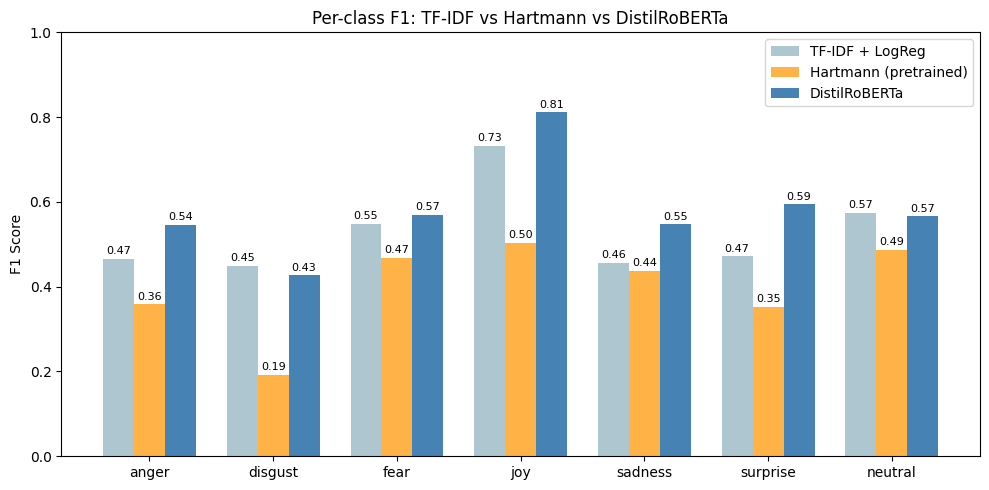

In [92]:
# ── Cell 15: Side-by-side F1 comparison plot ───────────────────────────────────

from sklearn.metrics import f1_score

tfidf_f1s    = f1_score(test_labels_np,  tfidf_preds,    average=None, labels=list(range(NUM_LABELS)))
hartmann_f1s = f1_score(hartmann_labels, hartmann_preds, average=None, labels=list(range(NUM_LABELS)))
roberta_f1s     = f1_score(bert_labels,     bert_preds,     average=None, labels=list(range(NUM_LABELS)))

x     = np.arange(NUM_LABELS)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width,   tfidf_f1s,    width, label="TF-IDF + LogReg",    color="#aec6cf")
bars2 = ax.bar(x,           hartmann_f1s, width, label="Hartmann (pretrained)", color="#ffb347")
bars3 = ax.bar(x + width,   roberta_f1s,     width, label="DistilRoBERTa",          color="#4682b4")

ax.set_xticks(x)
ax.set_xticklabels(EKMAN_LABELS)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.0)
ax.set_title("Per-class F1: TF-IDF vs Hartmann vs DistilRoBERTa")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=8)
ax.bar_label(bars3, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

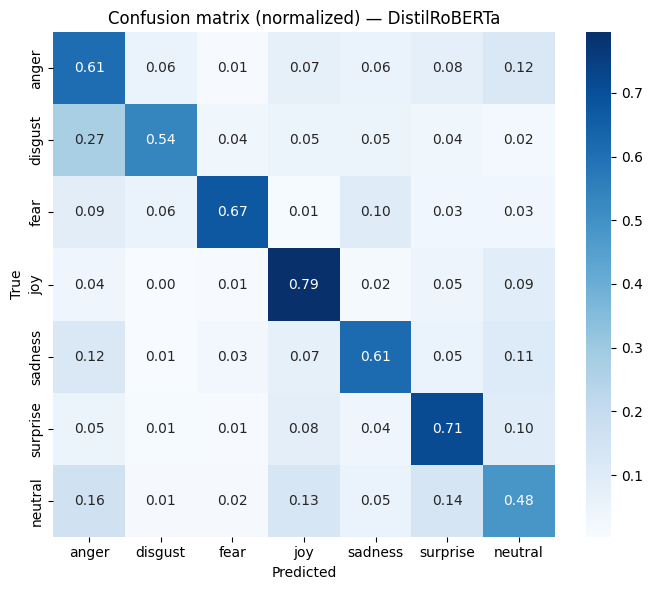

In [93]:
# ── Cell 16: Confusion matrix for DistilRoBERTa ───────────────────────────────────

cm = confusion_matrix(bert_labels, bert_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=EKMAN_LABELS,
    yticklabels=EKMAN_LABELS,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (normalized) — DistilRoBERTa")
plt.tight_layout()
plt.show()

In [94]:
# ─── 4.1  Load sarcasm model ─────────────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SARCASM_MODEL_CKPT = "jkhan447/sarcasm-detection-RoBerta-base-CR"

"""
This model is a fine-tuned version of roberta-base on the None dataset. It achieves the following results on the evaluation set:

    Loss: 0.6651
    Accuracy: 0.607
"""

sarcasm_tokenizer = AutoTokenizer.from_pretrained(SARCASM_MODEL_CKPT)
sarcasm_model     = AutoModelForSequenceClassification.from_pretrained(SARCASM_MODEL_CKPT).to(DEVICE)
sarcasm_model.eval()

def detect_sarcasm(text: str):
    inputs = sarcasm_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding="max_length"
    ).to(DEVICE)

    with torch.no_grad():
        logits = sarcasm_model(**inputs).logits
        probs  = torch.nn.functional.softmax(logits, dim=-1)

    sarc_score = probs[0, 1].item()
    label      = "sarcasm" if sarc_score > 0.5 else "not sarcasm"

    return label, round(sarc_score, 4)

# Smoke test
for t in [
    "Oh great, another Monday. Just what I needed.",
    "I genuinely love spending time with my family.",
    "Wow, what a fantastic idea. Truly groundbreaking.",
]:
    lbl, conf = detect_sarcasm(t)
    print(f"{lbl:<14} ({conf:.1%})  |  {t}")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12644.06it/s]


sarcasm        (100.0%)  |  Oh great, another Monday. Just what I needed.
not sarcasm    (0.0%)  |  I genuinely love spending time with my family.
sarcasm        (100.0%)  |  Wow, what a fantastic idea. Truly groundbreaking.


In [95]:
# ── Cell 20: Combined inference pipeline ──────────────────────────────────────
# Loads both saved models and runs the full pipeline:
# text → sarcasm score → emotion logits → post-processing → final label

import torch.nn.functional as F

# Load saved models
_emotion_tokenizer = AutoTokenizer.from_pretrained(EMOTION_OUTPUT_DIR)
_emotion_model     = AutoModelForSequenceClassification.from_pretrained(EMOTION_OUTPUT_DIR).to(device)
_emotion_model.eval()

def _encode(text, tok, max_len=MAX_LENGTH):
    return tok(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len,
    ).to(device)

SARCASM_THRESHOLD = 0.5   

def predict_emotion(text: str, sarcasm_threshold: float = SARCASM_THRESHOLD) -> dict:
    
    sarc_label, sarc_score = detect_sarcasm(text)
    is_sarcastic = sarc_label == "sarcasm"   # trust the label, drop threshold entirely

    with torch.no_grad():
        emo_enc    = _encode(text, _emotion_tokenizer)
        emo_logits = _emotion_model(**emo_enc).logits
        emo_probs  = F.softmax(emo_logits, dim=-1)
        emo_idx    = emo_probs.argmax().item()
        emo_conf   = emo_probs[0, emo_idx].item()

    flagged = False
    if is_sarcastic:
        if emo_conf > 0.75:
            emo_idx = SARCASM_FLIP_MAP[emo_idx]
        else:
            flagged = True   # sarcastic but emotion uncertain

    return {
        "text":          text,
        "emotion":       ID2LABEL[emo_idx],
        "confidence":    round(emo_conf, 3),
        "sarcasm_score": round(sarc_score, 3),
        "sarcasm_label": sarc_label,
        "is_sarcastic":  is_sarcastic,
        "flagged":       flagged,
        "all_probs":     {ID2LABEL[i]: round(p, 3) for i, p in enumerate(emo_probs[0].tolist())},
    }
    

print("Inference pipeline ready. Call predict_emotion(text).")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2670.83it/s]


Inference pipeline ready. Call predict_emotion(text).


In [96]:
# ── Cell 21: Test the pipeline ─────────────────────────────────────────────────

test_sentences = [
    "I can't believe she did that for me, I'm so grateful.",
    "Oh great, another Monday. Just what I needed.",
    "I'm terrified of what's going to happen next.",
    "That is absolutely disgusting, I can't even look at it.",
    "I didn't expect that at all — wow.",
    "Everything is falling apart and I don't know what to do.",
    "Oh fantastic, another email from the boss. Just what I wanted.",
]

print(f"{'Text':<55} {'Emotion':<10} {'Conf':>6} {'Sarc':>6} {'Is Sarcastic':<12} {'Flagged'}")
print("-" * 90)
for sent in test_sentences:
    r = predict_emotion(sent)
    preview = (sent[:52] + "...") if len(sent) > 55 else sent
    print(f"{preview:<55} {r['emotion']:<10} {r['confidence']:>6.3f} {r['sarcasm_score']:>6.3f} {r['is_sarcastic']:<12} {r['flagged']}")

Text                                                    Emotion      Conf   Sarc Is Sarcastic Flagged
------------------------------------------------------------------------------------------
I can't believe she did that for me, I'm so grateful.   sadness     0.902  1.000 1            False
Oh great, another Monday. Just what I needed.           sadness     0.914  1.000 1            False
I'm terrified of what's going to happen next.           fear        0.998  0.000 0            False
That is absolutely disgusting, I can't even look at it. disgust     0.998  0.000 0            False
I didn't expect that at all — wow.                      surprise    0.866  0.009 0            False
Everything is falling apart and I don't know what to... surprise    0.601  0.000 0            False
Oh fantastic, another email from the boss. Just what... sadness     0.981  1.000 1            False


In [97]:
# ── Cell 22: Error analysis — where does the model fail? ──────────────────────
# Find high-confidence wrong predictions. These are the most informative failures.

test_texts_list = remapped["test"]["text"]
true_labels     = np.array(remapped["test"]["label"])

# Get predictions + confidence for the test set (batch for speed)
from torch.utils.data import DataLoader

all_probs = []
_emotion_model.eval()

loader = DataLoader(tokenized["test"], batch_size=EVAL_BATCH_SIZE)
with torch.no_grad():
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = _emotion_model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs  = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

all_probs  = np.vstack(all_probs)
pred_labels = all_probs.argmax(axis=1)
confidences = all_probs.max(axis=1)

# Filter: wrong + high confidence
wrong_mask = pred_labels != true_labels
conf_mask  = confidences > 0.85
hard_wrong = np.where(wrong_mask & conf_mask)[0]

print(f"High-confidence errors (conf > 0.85): {len(hard_wrong)}")
print()
for idx in hard_wrong[:10]:   # show first 10
    print(f"Text:       {test_texts_list[idx][:80]}")
    print(f"True:       {ID2LABEL[true_labels[idx]]}")
    print(f"Predicted:  {ID2LABEL[pred_labels[idx]]} (conf: {confidences[idx]:.3f})")
    print()

High-confidence errors (conf > 0.85): 635

Text:       [NAME] has towed the line of the Dark Side. He wouldn't cross it by doing someth
True:       anger
Predicted:  neutral (conf: 0.874)

Text:       The thought of shooting anything at asylum seekers is appalling.
True:       fear
Predicted:  disgust (conf: 0.990)

Text:       Same here but it seems like that will make it more rewarding to actually build a
True:       neutral
Predicted:  joy (conf: 0.972)

Text:       What's that like? Like what's the thought process? I dunno. I know what's a weir
True:       neutral
Predicted:  surprise (conf: 0.977)

Text:       I totally thought the same thing! I was like, oh honey nooooo!
True:       neutral
Predicted:  surprise (conf: 0.878)

Text:       You didn't watch it to the end.
True:       anger
Predicted:  neutral (conf: 0.939)

Text:       You take that back right now! [NAME] does not deserve this.
True:       neutral
Predicted:  anger (conf: 0.960)

Text:       "I didn't know this was 